In [1]:
#Import Libraries
###Data Handling
import pandas as pd
import numpy as np

###Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

###Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load demand forecasting dataset
forecast_df = pd.read_csv('demand_forecasting.csv')

# View first 5 rows
forecast_df.head()

,Date,Store_ID,Item_ID,Sales,Promotion,Holiday,Region,Temperature,Fuel_Price
0,2023-01-01,1,101,47,No,No,North,30,3.83
1,2023-01-01,1,102,68,No,Yes,North,27,2.51
2,2023-01-01,1,103,98,Yes,No,East,31,3.97
3,2023-01-01,1,104,90,Yes,Yes,North,24,4.39
4,2023-01-01,1,105,46,No,No,South,30,2.85


In [3]:
#Shape Of Demand Forecasting Dataset:
forecast_df.shape

(4525, 9)

In [4]:
#Column Names in Demand Forecast Dataset
forecast_df.columns

Index(['Date', 'Store_ID', 'Item_ID', 'Sales', 'Promotion', 'Holiday',
       'Region', 'Temperature', 'Fuel_Price'],
      dtype='object')

In [5]:
#Check Datatypes in Demand Forecasting
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4525 entries, 0 to 4524
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         4525 non-null   object 
 1   Store_ID     4525 non-null   int64  
 2   Item_ID      4525 non-null   int64  
 3   Sales        4525 non-null   int64  
 4   Promotion    4525 non-null   object 
 5   Holiday      4525 non-null   object 
 6   Region       4525 non-null   object 
 7   Temperature  4525 non-null   int64  
 8   Fuel_Price   4525 non-null   float64
dtypes: float64(1), int64(4), object(4)
memory usage: 318.3+ KB


In [6]:
#Check Missing Values
forecast_df.isnull().sum()

Date           0
Store_ID       0
Item_ID        0
Sales          0
Promotion      0
Holiday        0
Region         0
Temperature    0
Fuel_Price     0
dtype: int64

In [7]:
#Convert Date Column into datetime Format
forecast_df['Date'] = pd.to_datetime(forecast_df['Date'])

In [8]:
forecast_df.head()

,Date,Store_ID,Item_ID,Sales,Promotion,Holiday,Region,Temperature,Fuel_Price
0,2023-01-01,1,101,47,No,No,North,30,3.83
1,2023-01-01,1,102,68,No,Yes,North,27,2.51
2,2023-01-01,1,103,98,Yes,No,East,31,3.97
3,2023-01-01,1,104,90,Yes,Yes,North,24,4.39
4,2023-01-01,1,105,46,No,No,South,30,2.85


In [9]:
# Create time-based features
forecast_df['Year'] = forecast_df['Date'].dt.year
forecast_df['Month'] = forecast_df['Date'].dt.month
forecast_df['Day'] = forecast_df['Date'].dt.day
forecast_df['Day_of_Week'] = forecast_df['Date'].dt.dayofweek
forecast_df['Week_of_Year'] = forecast_df['Date'].dt.isocalendar().week

In [10]:
forecast_df.head()

,Date,Store_ID,Item_ID,Sales,Promotion,Holiday,Region,Temperature,Fuel_Price,Year,Month,Day,Day_of_Week,Week_of_Year
0,2023-01-01,1,101,47,No,No,North,30,3.83,2023,1,1,6,52
1,2023-01-01,1,102,68,No,Yes,North,27,2.51,2023,1,1,6,52
2,2023-01-01,1,103,98,Yes,No,East,31,3.97,2023,1,1,6,52
3,2023-01-01,1,104,90,Yes,Yes,North,24,4.39,2023,1,1,6,52
4,2023-01-01,1,105,46,No,No,South,30,2.85,2023,1,1,6,52


In [11]:
# Demand forecasting dataset summary statistics
forecast_df.describe()

,Date,Store_ID,Item_ID,Sales,Temperature,Fuel_Price,Year,Month,Day,Day_of_Week,Week_of_Year
count,4525,4525.00000,4525.00000,4525.000000,4525.000000,4525.000000,4525.0,4525.000000,4525.000000,4525.000000,4525.0
mean,2023-04-01 00:00:00,3.00000,103.00000,59.419890,30.147182,3.495777,2023.0,3.508287,15.602210,2.988950,13.574586
min,2023-01-01 00:00:00,1.00000,101.00000,20.000000,20.000000,2.500000,2023.0,1.000000,1.000000,0.000000,1.0
25%,2023-02-15 00:00:00,2.00000,102.00000,39.000000,25.000000,2.990000,2023.0,2.000000,8.000000,1.000000,7.0
50%,2023-04-01 00:00:00,3.00000,103.00000,59.000000,30.000000,3.500000,2023.0,4.000000,16.000000,3.000000,13.0
75%,2023-05-16 00:00:00,4.00000,104.00000,79.000000,35.000000,4.010000,2023.0,5.000000,23.000000,5.000000,20.0
max,2023-06-30 00:00:00,5.00000,105.00000,100.000000,40.000000,4.500000,2023.0,6.000000,31.000000,6.000000,52.0
std,NaN,1.41437,1.41437,23.157049,6.046240,0.583280,0.0,1.710149,8.736287,2.000191,7.93926


In [12]:
# Average sales by month
forecast_df.groupby('Month')['Sales'].mean()

Month
1    61.077419
2    58.468571
3    58.882581
4    58.674667
5    59.766452
6    59.537333
Name: Sales, dtype: float64

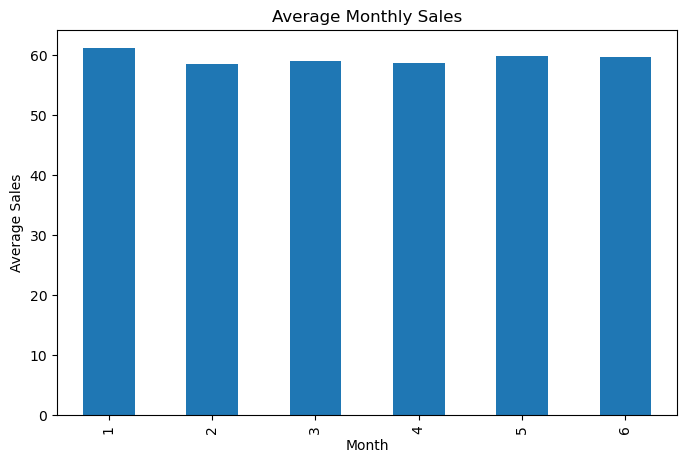

In [13]:
# Monthly average sales plot
forecast_df.groupby('Month')['Sales'].mean().plot(kind='bar', figsize=(8,5))

plt.title('Average Monthly Sales')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

In [14]:
###Insight
#Month 1 having the highest sales suggests strong demand at the beginning of the year

In [15]:
# Average sales by day of week
forecast_df.groupby('Day_of_Week')['Sales'].mean()

Day_of_Week
0    58.252308
1    60.383077
2    58.815385
3    59.484615
4    59.324615
5    59.571200
6    60.113846
Name: Sales, dtype: float64

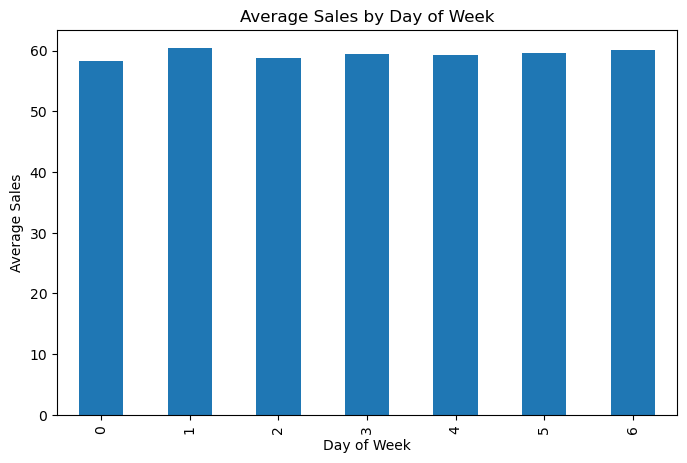

In [16]:
forecast_df.groupby('Day_of_Week')['Sales'].mean().plot(kind='bar', figsize=(8,5))

plt.title('Average Sales by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Sales')
plt.show()

In [17]:
# Convert Promotion and Holiday to numeric
forecast_df['Promotion'] = forecast_df['Promotion'].map({'Yes': 1, 'No': 0})
forecast_df['Holiday'] = forecast_df['Holiday'].map({'Yes': 1, 'No': 0})

In [18]:
# One-hot encoding for Region
forecast_df = pd.get_dummies(forecast_df, columns=['Region'], drop_first=True)

In [19]:
forecast_df.head()

,Date,Store_ID,Item_ID,Sales,Promotion,Holiday,Temperature,Fuel_Price,Year,Month,Day,Day_of_Week,Week_of_Year,Region_North,Region_South,Region_West
0,2023-01-01,1,101,47,0,0,30,3.83,2023,1,1,6,52,True,False,False
1,2023-01-01,1,102,68,0,1,27,2.51,2023,1,1,6,52,True,False,False
2,2023-01-01,1,103,98,1,0,31,3.97,2023,1,1,6,52,False,False,False
3,2023-01-01,1,104,90,1,1,24,4.39,2023,1,1,6,52,True,False,False
4,2023-01-01,1,105,46,0,0,30,2.85,2023,1,1,6,52,False,True,False


# Define Features (X) and Target (y)

In [20]:
# Define target variable
y_forecast = forecast_df['Sales']

# Drop unnecessary columns
X_forecast = forecast_df.drop(['Sales', 'Date'], axis=1)

# Train - Test Split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_forecast, y_forecast, test_size=0.2, random_state=42
)

# Import Model

In [23]:
from sklearn.ensemble import RandomForestRegressor

In [24]:
# Create model
rf_forecast = RandomForestRegressor(n_estimators=100, random_state=42)

# Train model
rf_forecast.fit(Xf_train, yf_train)

# Predict on test data
yf_pred = rf_forecast.predict(Xf_test)

# Model Evaluation

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [26]:
mae_f = mean_absolute_error(yf_test, yf_pred)
rmse_f = np.sqrt(mean_squared_error(yf_test, yf_pred))

mae_f, rmse_f

(20.53645303867403, np.float64(23.994406882802057))

# Feature Importance

In [27]:
import pandas as pd

importance_forecast = pd.DataFrame({
    'Feature': X_forecast.columns,
    'Importance': rf_forecast.feature_importances_
})

importance_forecast = importance_forecast.sort_values(
    by='Importance',
    ascending=False
)

importance_forecast.head(10)

,Feature,Importance
5,Fuel_Price,0.227025
8,Day,0.148506
4,Temperature,0.146791
10,Week_of_Year,0.095242
9,Day_of_Week,0.085478
1,Item_ID,0.073022
0,Store_ID,0.072751
7,Month,0.031698
3,Holiday,0.029075
2,Promotion,0.028528


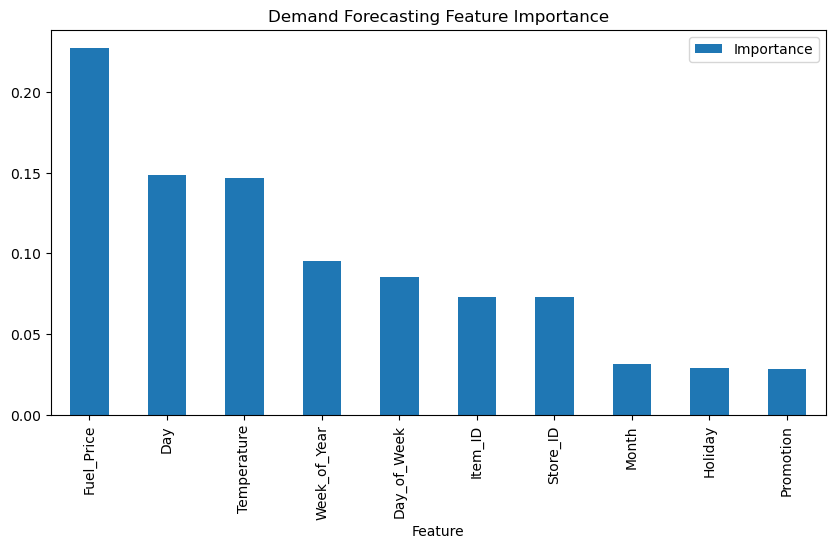

In [28]:
importance_forecast.head(10).plot(
x='Feature',
y='Importance',
kind='bar',
figsize=(10,5)
)

plt.title('Demand Forecasting Feature Importance')
plt.show()

# Install XGBOOST

In [29]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
from xgboost import XGBRegressor

In [31]:
xgb_forecast = XGBRegressor(
n_estimators=200,
learning_rate=0.05,
max_depth=6,
random_state=42
)

xgb_forecast.fit(Xf_train, yf_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
#Predict
yf_pred_xgb = xgb_forecast.predict(Xf_test)

In [33]:
#Evaluate
mae_fxgb = mean_absolute_error(yf_test, yf_pred_xgb)
rmse_fxgb = np.sqrt(mean_squared_error(yf_test, yf_pred_xgb))

mae_fxgb, rmse_fxgb

(20.890039443969727, np.float64(24.524456662877874))

In [34]:
###Insight
#Compared Random Forest and XGBoost for demand forecasting and selected Random Forest based on lower prediction error (MAE/RMSE), demonstrating model evaluation and selection.

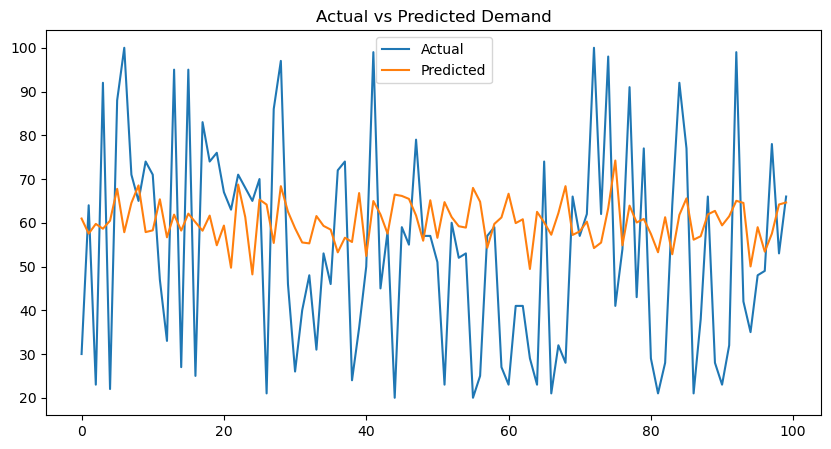

In [35]:
# Prediction Plot
plt.figure(figsize=(10,5))

plt.plot(
yf_test.values[:100],
label='Actual'
)

plt.plot(
yf_pred[:100],
label='Predicted'
)

plt.legend()
plt.title('Actual vs Predicted Demand')
plt.show()

In [36]:
#r2_score:
from sklearn.metrics import r2_score

In [37]:
r2_score(yf_test,yf_pred)

-0.04351820820863517

In [38]:
### Insight 
#Evaluated models using MAE, RMSE and R²; identified limited explanatory power and proposed feature engineering improvements including lag and rolling-window features.

# Lag Features

In [39]:
# Sort Data Properly
forecast_df = forecast_df.sort_values(
by = ['Store_ID','Item_ID','Date'])

In [40]:
# Create Lag Features
# Previous Days Sales
forecast_df['Lag_1'] = (
forecast_df.groupby(
['Store_ID','Item_ID']
)['Sales'].shift(1)
)

In [41]:
# Create 7 Day lag
forecast_df['Lag_7'] = (
forecast_df.groupby(
['Store_ID','Item_ID']
)['Sales'].shift(7)
)
#This will capture weekly pattern

In [42]:
# Rolling Average Feature
forecast_df['Rolling_Mean_7'] = (
forecast_df.groupby(
['Store_ID','Item_ID']
)['Sales']
.transform(
lambda x: x.shift(1).rolling(7).mean()
)
)

In [43]:
#Check missing values created by lags
forecast_df.isnull().sum()

Date                0
Store_ID            0
Item_ID             0
Sales               0
Promotion           0
Holiday             0
Temperature         0
Fuel_Price          0
Year                0
Month               0
Day                 0
Day_of_Week         0
Week_of_Year        0
Region_North        0
Region_South        0
Region_West         0
Lag_1              25
Lag_7             175
Rolling_Mean_7    175
dtype: int64

In [44]:
#Drop lag-generated missing rows
forecast_df = forecast_df.dropna()

# Redefine Features

In [45]:
# Target
y_forecast = forecast_df['Sales']

# Features (drop Sales and Date again)
X_forecast = forecast_df.drop(['Sales', 'Date'], axis=1)

# Train Test Split

In [46]:
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_forecast, y_forecast, test_size=0.2, random_state=42
)

# Train Model

In [47]:
rf_forecast = RandomForestRegressor(n_estimators=100, random_state=42)

rf_forecast.fit(Xf_train, yf_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [48]:
# Predict
yf_pred = rf_forecast.predict(Xf_test)

# Evaluate Again

In [49]:
mae_f = mean_absolute_error(yf_test, yf_pred)
rmse_f = np.sqrt(mean_squared_error(yf_test, yf_pred))

mae_f, rmse_f

(20.860379310344825, np.float64(24.167022988257006))

In [50]:
r2_score(yf_test, yf_pred)

-0.04366011955539273

In [52]:
###Insight
#Despite introducing lag and rolling features, model performance did not improve significantly due to lack of inherent temporal patterns in the dataset. 
#This highlights the importance of real-world data quality and feature relevance in time-series forecasting.

In [53]:
import pickle

with open('model_forecast.pkl', 'wb') as f:
    pickle.dump(rf_forecast, f)